## RNN의 단점 : 기울기 소실 (Gradient Vanishing)

### 기울기 소실(Gradient Vanishing) 발생 과정

기울기 소실 **RNN이 긴 시퀀스 데이터를 처리할 때 발생하는 문제**입니다.

---
### 1. 역전파 과정의 문제

RNN은 학습 과정에서 **시간 기반 역전파(BPTT, Backpropagation Through Time)** 를 사용합니다.

* 출력층에서 계산된 **오차(loss)** 를 이용해 **출력** -> **입력 방향**으로 기울기(gradient)를 전달하여 가중치를 업데이트합니다.

### 2. 반복적인 곱셈

시퀀스가 길어질수록 **각 단계에서 기울기가 반복적으로 곱해집니다.**

예를 들어,

$0.5$ x $0.5$ x $0.5$ x $0.5$ x $0.5$

처럼 계속 곱해지면

$0.5^5$ = $0.03125$

더 길어지면

$0.5^10$ = $0.00097$

### 3. 결과

기울기가 매우 작아지면 다음 문제가 발생합니다.

* 앞쪽 시점의 **가중치가 거의 업데이트되지 않습니다.**
* 따라서 **오래된 정보(과거 정보)** 를 학습하기 어려워집니다.
* 이를 **장기 의존성 문제(Long-term Dependency Problem)** 라고 합니다.

---
## 정리

RNN에서는 시퀀스가 길어질수록 역전파 과정에서 **기울기가 반복적으로 곱해지면서 점점 작아지고,**  
결국 **앞쪽 단계의 가중치가 제대로 학습되지 않는 기울기 소실(Gradient Vanishing) 문제가 발생합니다.**

---
## 2. LSTM (Long Short-Term Memory)

LSTM은 **RNN의 기울기 소실(Gradient Vanishing) 문제를 보완하기 위해 설계된 순환 신경망 구조**입니다.

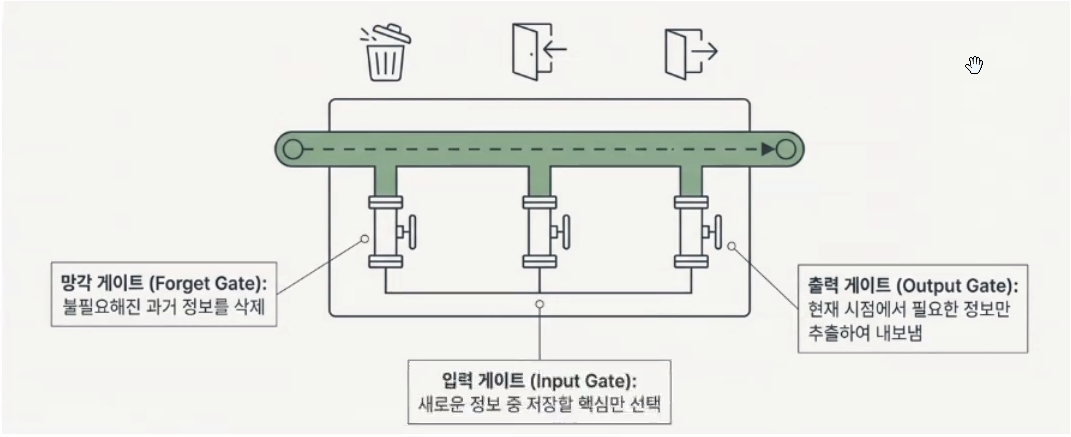

### 2-1. 핵심 개념 : 셀 상태 (Cell State)

LSTM은 **셀 상태(Cell State)** 라는 별도의 기억 통로를 사용합니다.

* 셀 상태는 **컨베이어 벨트와 같은 역할**을 합니다.
* 이 벨트는 문장의 맨 처음부터 끝까지 흐르면서 정보를 전달합니다.
* 셀 상태는 큰 변형 없이 다음 단계로 전달되기 때문에, **과거 정보가 비교적 오래 유지될 수 있습니다.**
* 하지만 정보가 그대로 유지되는 것은 아니며, **게이트(Gate) 구조를 통해 필요한 정보는 유지하고 불필요한 정보는 제거합니다.**

---

### 2-2. 게이트(Gate) 구조

LSTM에서 게이트(Gate)는 한마디로 "정보의 흐름을 조절하는 밸브(Valve) 또는 필터"라고 정의할 수 있습니다.

LSTM은 세 가지 게이트를 사용하여 정보를 제어합니다.

각 게이트는 **시그모이드(sigmoid) 함수를 사용하여 0~1 사이의 값을 만들어 정보의 흐름을 조절합니다.**

* 값이 **0에 가까우면 정보가 거의 전달되지 않습니다.**
* 값이 **1에 가까우면 정보가 그대로 전달됩니다.**


### (1) 망각 게이트 (Forget Gate)

과거 정보 중에서 **버릴 정보를 결정**합니다.

* 필요 없는 정보 $\rightarrow$ 제거
* 중요한 정보 $\rightarrow$ 유지

망각 게이트는 현재 입력과 이전 은닉 상태를 이용해 **0~1 사이의 값을 계산**하고, 이 값을 **이전 셀 상태에 곱하여 불필요한 정보를 줄이거나 제거합니다.**

* 예) 나는 어제 영화를 봤다. 오늘은 시험이 있다.
* 모델이 현재 단어 "시험"을 처리할 때 "어제 영화를" 정보는 현재 문맥에서 덜 중요할 수 있습니다.
* 이 경우 망각 게이트가 **0에 가까운 값을 만들어 해당 정보의 영향을 줄입니다.**


### (2) 입력 게이트 (Input Gate)

현재 입력 정보 중에서 **셀 상태에 저장할 정보를 선택**합니다.

* 새로운 정보 중 **중요한 것만 저장**합니다.

### (3) 출력 게이트 (Output Gate)

업데이트된 셀 상태를 기반으로 **다음 시점으로 전달할 출력 정보를 결정**합니다.

출력 게이트는 **셀 상태(Cell State)** 를 이용하여 현재 시점의 **은닉 상태(Hidden State)** 를 생성합니다.

### 정리

LSTM은 **셀 상태(Cell State)** 와 **게이트(Gate) 구조**를 사용하여

* 중요한 정보는 **오랫동안 유지하고**
* 불필요한 정보는 **선택적으로 제거**

할 수 있습니다.

그래서 LSTM은 **긴 문장이나 긴 시계열 데이터 학습에 유리한 모델**입니다.





---
## LSTM 신경망 훈련하기

In [1]:
from keras.datasets import imdb
from sklearn.model_selection import train_test_split

(train_input, train_target), (test_input, test_target) = imdb.load_data(
    num_words = 500)

train_input, val_input, train_target, val_target = train_test_split(
    train_input, train_target, test_size=0.2, random_state=42)

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


c:\workspace\ML_DL\venv\Lib\site-packages\numpy\lib\_format_impl.py:838: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  array = pickle.load(fp, **pickle_kwargs)


In [2]:
from keras.preprocessing.sequence import pad_sequences
train_seq = pad_sequences(train_input, maxlen=100)
val_seq = pad_sequences(val_input, maxlen=100)

In [3]:
from tensorflow import keras

model = keras.Sequential()

# 한 샘플이 길이 100인 정수 시퀀스라는 뜻입니다.
model.add(keras.layers.Input(shape=(100,)))

# Embedding 층 파라미터 수
# 어휘 사전 크기(vocab_size)=500, 임베딩 벡터 크기(embedding_dim)=16
# 각 단어는 16차원 벡터로 표현됩니다.
# 파라미터 수 = 500 x 16 = 8000
model.add(keras.layers.Embedding(500,16))

# LSTM 층 파라미터 수

# 입력 크기(input_dim)=16, 유닛 수(units)=8

# 입력 가중치: 16 x 8 = 128
# 순환 가중치: 8 x 8 = 64
# 편향(bias): 8

# LSTM 내부 계산 1개(게이트 또는 Cell Candidate) 당 파라미터 수
# 128 + 64 + 8 = 200

# LSTM은 4개의 계산을 수행
# (Forget Gate, Input Gate, Cell Candidate, Output Gate)

# 총 파라미터 수
# 200 x 4 = 800

# LSTM에서 8은 시간마다 유지되는 기억 벡터의 크기
# (은닉 상태 차원, hidden state size)
model.add(keras.layers.LSTM(8))


# Dense 층 파라미터 수
# 입력 뉴런 수 = 8, 출력 뉴런 수 = 1
# 가중치: 8 x 1 = 8
# 편향(bias): 1
# 총 파라미터 수: 8 + 1 = 9
model.add(keras.layers.Dense(1, activation='sigmoid'))

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 100, 16)        │         8,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 8)              │           800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,809 (34.41 KB)

 Trainable params: 8,809 (34.41 KB)

 Non-trainable params: 0 (0.00 B)

In [4]:
model.compile(optimizer='adam',  loss='binary_crossentropy', 
                        metrics=['accuracy'])


checkpoint_cb = keras.callbacks.ModelCheckpoint('best-lstm-model.keras', 
                                                save_best_only=True)


early_stopping_cb = keras.callbacks.EarlyStopping(patience=3, 
                                                                    restore_best_weights=True)

history = model.fit(train_seq, train_target, epochs=100, batch_size=64,
                    validation_data=(val_seq, val_target),
                    callbacks=[checkpoint_cb, early_stopping_cb])


Epoch 1/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.6982 - loss: 0.5814 - val_accuracy: 0.7242 - val_loss: 0.5456
Epoch 2/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.7875 - loss: 0.4592 - val_accuracy: 0.7978 - val_loss: 0.4397
Epoch 3/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.7987 - loss: 0.4337 - val_accuracy: 0.7960 - val_loss: 0.4368
Epoch 4/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.8019 - loss: 0.4275 - val_accuracy: 0.7956 - val_loss: 0.4353
Epoch 5/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.8090 - loss: 0.4158 - val_accuracy: 0.7938 - val_loss: 0.4463
Epoch 6/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.8112 - loss: 0.4111 - val_accuracy: 0.8016 - val_loss: 0.4294
Epoch 7/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.8145 - loss: 0.4012 - val_accuracy: 0.7990 - val_loss: 0.4417
Epoch 8/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.8169 - loss: 0.3965 - val_acc

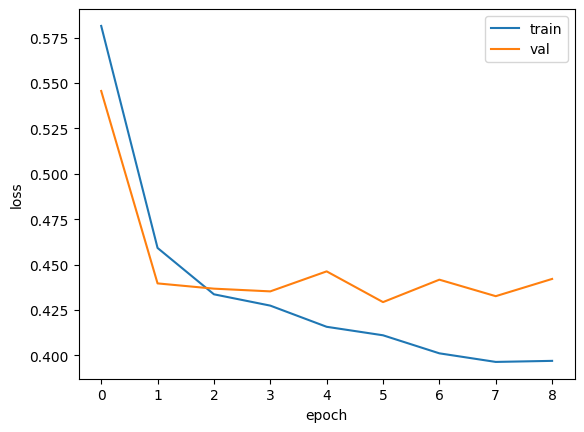

In [5]:
import matplotlib.pyplot as plt


plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend(['train', 'val'])
plt.show()

## 순환 층에 드롭아웃 적용하기

In [6]:
from tensorflow import keras

# Sequential 모델 생성
model_dropout = keras.Sequential()

# 입력 데이터의 크기 정의 (한 문장의 단어 개수가 100개임을 의미)
model_dropout.add(keras.layers.Input(shape=(100,)))

# 임베딩 층 (단어의 '의미'를 숫자의 나열로 변환)
# 500: 사용할 단어 사전의 크기 (총 500 종류의 단어 취급)
# 16: 각 단어를 16개의 숫자(차원)로 표현 (예: '사과' -> [0.1, -0.2, ...])
model_dropout.add(keras.layers.Embedding(500, 16))

# LSTM 층 (순차 데이터의 맥락을 파악하는 핵심 단계)
# 8: 메모리 셀의 개수 (출력되는 벡터의 크기)
# dropout=0.2: 학습 시 입력 데이터의 20%를 무작위로 0으로 만들어 과적합 방지
model_dropout.add(keras.layers.LSTM(8, dropout=0.2)) # 입력값 20%를 무작위로 꺼서 과적합을 방지함
                                                    # [0.12, -0.45, 0.88, 0.03, ..., 0.51] (16차원) -> [0.12, 0.00, 0.88, 0.03, ..., 0.00] 일부 값이 무작위로 0

# 출력 층 (최종 판단 단계)
# 1: 출력 노드 개수 (결과값 1개)
# activation='sigmoid': 출력을 0과 1 사이로 압축 (이진 분류: 예/아니오, 긍정/부정 판단용)
model_dropout.add(keras.layers.Dense(1, activation='sigmoid'))

model_dropout.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (None, 100, 16)        │         8,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 8)              │           800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,809 (34.41 KB)

 Trainable params: 8,809 (34.41 KB)

 Non-trainable params: 0 (0.00 B)

In [7]:
model_dropout.compile(optimizer='adam',  loss='binary_crossentropy', 
                        metrics=['accuracy'])


checkpoint_cb = keras.callbacks.ModelCheckpoint('best-dropuot-model.keras', 
                                                save_best_only=True)


early_stopping_cb = keras.callbacks.EarlyStopping(patience=3, 
                                                                    restore_best_weights=True)

history = model_dropout.fit(train_seq, train_target, epochs=100, batch_size=64,
                    validation_data=(val_seq, val_target),
                    callbacks=[checkpoint_cb, early_stopping_cb])


Epoch 1/100


313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.6701 - loss: 0.5960 - val_accuracy: 0.7748 - val_loss: 0.4897
Epoch 2/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.7821 - loss: 0.4714 - val_accuracy: 0.7746 - val_loss: 0.4771
Epoch 3/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.7936 - loss: 0.4445 - val_accuracy: 0.7964 - val_loss: 0.4328
Epoch 4/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.8045 - loss: 0.4293 - val_accuracy: 0.7960 - val_loss: 0.4331
Epoch 5/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.8087 - loss: 0.4175 - val_accuracy: 0.7996 - val_loss: 0.4255
Epoch 6/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.8110 - loss: 0.4122 - val_accuracy: 0.8066 - val_loss: 0.4231
Epoch 7/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.8158 - loss: 0.4060 - val_accuracy: 0.7924 - val_loss: 0.4453
Epoch 8/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.8169 - loss: 0.4016 - val_accuracy

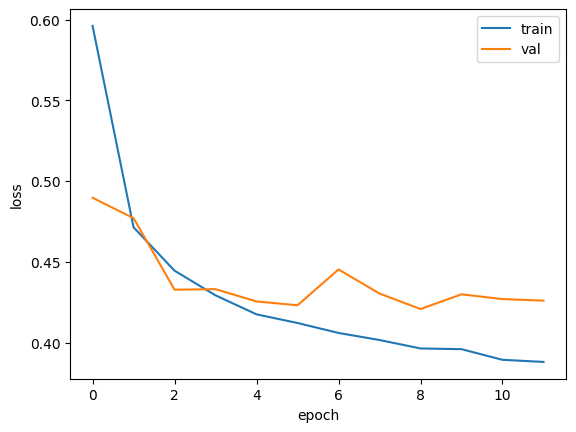

In [8]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend(['train', 'val'])
plt.show()

---
## GRU 신경망 훈련하기

* Gated Recurrent Unit의 약자로 RNN(순환 신경망)의 한 종류입니다.

* LSTM과 마찬가지로 시계열 데이터, 자연어 처리, 음성, 시계열 예측 등에 많이 사용됩니다.

* LSTM을 단순화 한것이 GRU입니다.

* GRU에는 2개의 게이트만 있습니다.   
    ① 업데이트 게이트 (Update Gate, z)

    * LSTM의 Forget + Input gate 역할을 합친 것
    * 과거 정보를 얼마나 유지할지, 새로운 정보를 얼마나 반영할지 결정

  ② 리셋 게이트 (Reset Gate, r)

    * 과거 정보를 얼마나 무시할지, 현재 입력을 더 강조할지 결정

* 은닉 상태 하나만 관리합니다.

* 셀 상태(cell state)가 없습니다.

* 데이터가 적거나 모델을 단순하게 하고 싶을 때 GRU가 유리합니다.

In [9]:

model_gru = keras.Sequential()
model_gru.add(keras.layers.Input(shape=(100,)))

model_gru.add(keras.layers.Embedding(500, 16))
model_gru.add(keras.layers.GRU(8))
model_gru.add(keras.layers.Dense(1, activation='sigmoid'))

model_gru.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ (None, 100, 16)        │         8,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ (None, 8)              │           624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,633 (33.72 KB)

 Trainable params: 8,633 (33.72 KB)

 Non-trainable params: 0 (0.00 B)

In [10]:
model_gru.compile(optimizer='adam',  loss='binary_crossentropy', 
                        metrics=['accuracy'])


checkpoint_cb = keras.callbacks.ModelCheckpoint('best-gru-model.keras', 
                                                save_best_only=True)


early_stopping_cb = keras.callbacks.EarlyStopping(patience=3, 
                                                                    restore_best_weights=True)

history = model_gru.fit(train_seq, train_target, epochs=100, batch_size=64,
                    validation_data=(val_seq, val_target),
                    callbacks=[checkpoint_cb, early_stopping_cb])


Epoch 1/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.6575 - loss: 0.6062 - val_accuracy: 0.7160 - val_loss: 0.5545
Epoch 2/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.7746 - loss: 0.4809 - val_accuracy: 0.7834 - val_loss: 0.4630
Epoch 3/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.7975 - loss: 0.4472 - val_accuracy: 0.7760 - val_loss: 0.4681
Epoch 4/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.7979 - loss: 0.4429 - val_accuracy: 0.7934 - val_loss: 0.4387
Epoch 5/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.8068 - loss: 0.4255 - val_accuracy: 0.7918 - val_loss: 0.4451
Epoch 6/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.8108 - loss: 0.4147 - val_accuracy: 0.8030 - val_loss: 0.4316
Epoch 7/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.8124 - loss: 0.4102 - val_accuracy: 0.8026 - val_loss: 0.4327
Epoch 8/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.8176 - loss: 0.4013 - 

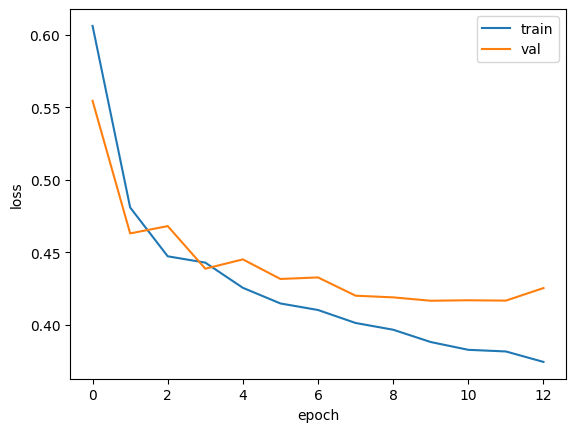

In [11]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend(['train', 'val'])
plt.show()

In [12]:
word_to_index = imdb.get_word_index()

def predict_review(a):
    words = a.lower().split()
    enc = []

    for word in words:
        index = word_to_index.get(word, 0) + 3 
        if index >= 500:
            index = 2
        enc.append(index)

    pad = pad_sequences([enc], maxlen=100)
    score = model_gru.predict(pad, verbose=0)[0][0]
    
    if score > 0.5:
        print(f"{score * 100:.2f}% 확률로 [긍정] 리뷰입입니다.")
    else:
        print(f"{(1 - score) * 100:.2f}% 확률로 [부정] 리뷰입니다.")


1641221/1641221 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [13]:
predict_review("this movie was no bad and boring")
predict_review("it was the best movie ever i love it")
predict_review("I was bored to death")
predict_review("It was a complete mess")

91.79% 확률로 [부정] 리뷰입니다.
97.12% 확률로 [긍정] 리뷰입입니다.
66.50% 확률로 [긍정] 리뷰입입니다.
77.62% 확률로 [긍정] 리뷰입입니다.
